# Bessel function of the first kind (J0)

**MLP**

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jn    # import Bessel function of the first kind

import torch
import torch.nn as nn
import torch.optim as optim

In [47]:
class MLP_2_2_1(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 2),   # input layer (2 variables -> 2 nodes)
            nn.ReLU(),
            nn.Linear(2, 2),   # hidden layer
            nn.ReLU(),
            nn.Linear(2, 1)    # output layer
        )

    def forward(self, x):
        return self.model(x)

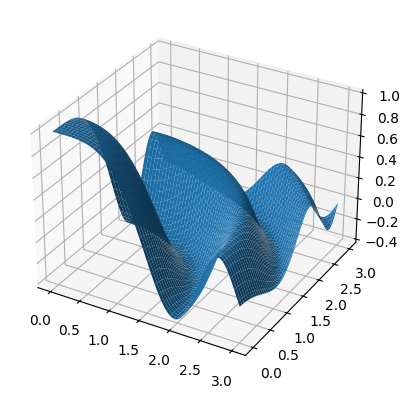

In [48]:
x = np.linspace(0, 3, 100) 
y = np.linspace(0, 3, 100)
x, y = np.meshgrid(x, y)

f = lambda x,y: jn(0, x**2 + y**2)  # Bessel function of the first kind, order 0

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, f(x, y))

In [53]:
# Convert to PyTorch input format (N,2)
X = torch.tensor(
    np.stack([x.ravel(), y.ravel()], axis=1),
    dtype=torch.float32
)

bessel = torch.tensor(jn(0, X[:, 0].numpy()**2 + X[:, 1].numpy()**2), dtype=torch.float32).view(-1, 1)

# Initialize model
model = MLP_2_2_1()

# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
epochs = 2000

for epoch in range(epochs):
    # Forward pass
    y_pred = model(X)
    loss = criterion(y_pred, bessel)

    # Backprop
    optimizer.zero_grad()   # claers old gradients from the previous iteration
    loss.backward()         # computes the gradient of the loss w.r.t. each parameter
    optimizer.step()        # updates the parameters based on the computed gradients

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 0.603996
Epoch 200, Loss: 0.132533
Epoch 400, Loss: 0.111925
Epoch 600, Loss: 0.047215
Epoch 800, Loss: 0.045493
Epoch 1000, Loss: 0.045431
Epoch 1200, Loss: 0.045430
Epoch 1400, Loss: 0.045430
Epoch 1600, Loss: 0.045430
Epoch 1800, Loss: 0.045430


In [54]:
x_grid = np.linspace(0, 3, 101)
y_grid = np.linspace(0, 3, 101)

X1_grid, X2_grid = np.meshgrid(x_grid, y_grid)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32
)

# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z = model(grid_points).numpy()

# Reshape to grid
Z = Z.reshape(X1_grid.shape)

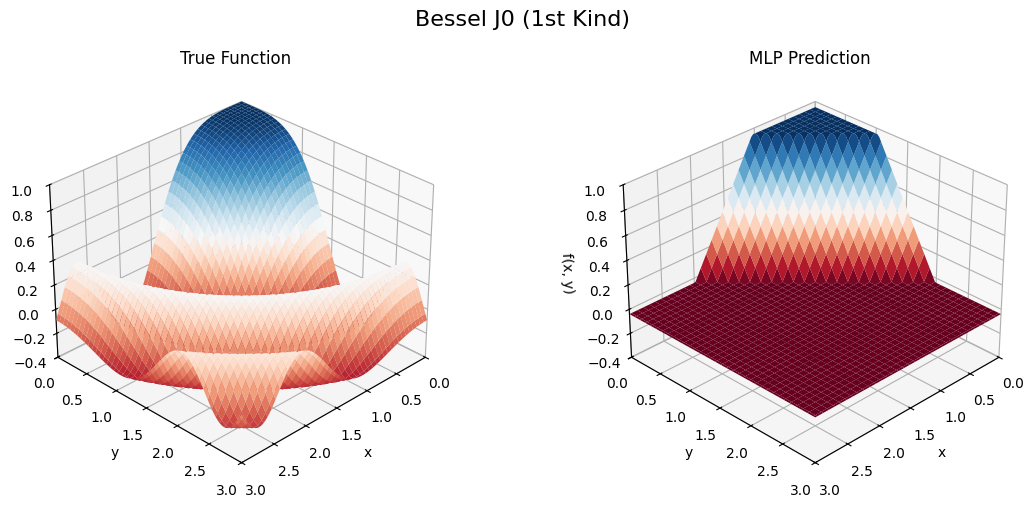

In [55]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(x, y, f(x, y), cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("x")
ax1.set_ylabel("y")

# --- MLP prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z, cmap='RdBu')

ax2.set_title("MLP Prediction")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("f(x, y)")

# --- Make axes identical ---
zmin = min(f(x,y).min(), Z.min())
zmax = max(f(x,y).max(), Z.max())

for ax in [ax1, ax2]:
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Bessel J0 (1st Kind)", fontsize=16)
plt.tight_layout()
plt.show()

**KAN**

In [38]:
from kan import *
from kan.spline import *
import torch
import matplotlib.pyplot as plt
from scipy.special import jn    # import Bessel function of the first kind

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [56]:
f_KAN = lambda x: jn(0, x[:,[0]]**2 + x[:,[1]]**2)  # Bessel function of the first kind, order 0

bessel_KAN = KAN(width=[2,2,1], grid=3, k=3, seed=1, device=device) # a [2,2,1] tree

dataset = create_dataset(f_KAN, n_var=2, ranges=[0, 3], train_num=100, device=device)
    # generate 2D train_input, 1D train_label (output), 2D test_input, 1D test_label (output)
    # 2D inputs are randomly generated within the specified range

checkpoint directory created: ./model
saving model version 0.0


In [57]:
bessel_KAN.fit(dataset, opt='LBFGS', steps=2000)

| train_loss: 3.69e-02 | test_loss: 1.30e-01 | reg: 8.57e+00 | : 100%|█| 2000/2000 [00:19<00:00, 100


saving model version 0.1


{'train_loss': [array(0.09496002, dtype=float32),
  array(0.04973901, dtype=float32),
  array(0.03633227, dtype=float32),
  array(0.03314546, dtype=float32),
  array(0.031739, dtype=float32),
  array(0.07609129, dtype=float32),
  array(0.07011212, dtype=float32),
  array(0.06774013, dtype=float32),
  array(0.06375244, dtype=float32),
  array(0.06165913, dtype=float32),
  array(0.0642252, dtype=float32),
  array(0.06379765, dtype=float32),
  array(0.06277256, dtype=float32),
  array(0.06182021, dtype=float32),
  array(0.05922721, dtype=float32),
  array(0.06038681, dtype=float32),
  array(0.0588745, dtype=float32),
  array(0.05757472, dtype=float32),
  array(0.05469773, dtype=float32),
  array(0.05038214, dtype=float32),
  array(0.05313715, dtype=float32),
  array(0.05248806, dtype=float32),
  array(0.05149153, dtype=float32),
  array(0.05033676, dtype=float32),
  array(0.04967947, dtype=float32),
  array(0.04981451, dtype=float32),
  array(0.04889276, dtype=float32),
  array(0.04807772

In [58]:
x_grid = np.linspace(0, 3, 101)
y_grid = np.linspace(0, 3, 101)
X1_grid, X2_grid = np.meshgrid(x_grid, y_grid)

Z_true = jn(0, X1_grid**2 + X2_grid**2)

# Convert grid to tensor input
grid_points = torch.tensor(
    np.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1),
    dtype=torch.float32,
    device=device
)


# Get model predictions
with torch.no_grad():       # temporarily disables gradient tracking
    Z_pred = bessel_KAN(grid_points).numpy()

# Reshape to grid
Z_pred = Z_pred.reshape(X1_grid.shape)


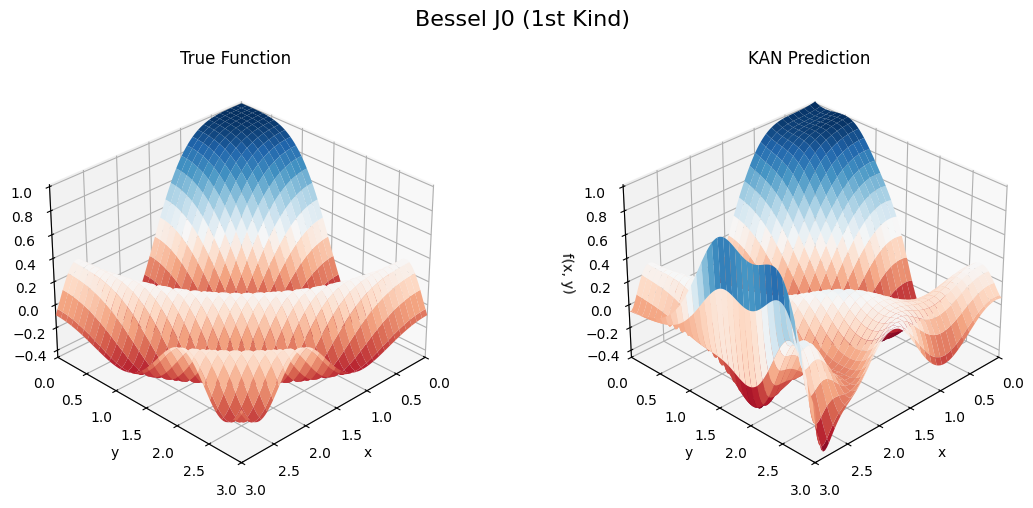

In [59]:
# Plot colormap
fig = plt.figure(figsize=(12,5))

# --- True function ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X1_grid, X2_grid, Z_true, cmap='RdBu')

ax1.set_title("True Function")
ax1.set_xlabel("x")
ax1.set_ylabel("y")

# --- KAN prediction ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X1_grid, X2_grid, Z_pred, cmap='RdBu')

ax2.set_title("KAN Prediction")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("f(x, y)")

# --- Make axes identical ---
zmin = min(Z_true.min(), Z_pred.min())
zmax = max(Z_true.max(), Z_pred.max())

for ax in [ax1, ax2]:
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=30, azim=45)

plt.suptitle("Bessel J0 (1st Kind)", fontsize=16)
plt.tight_layout()
plt.show()

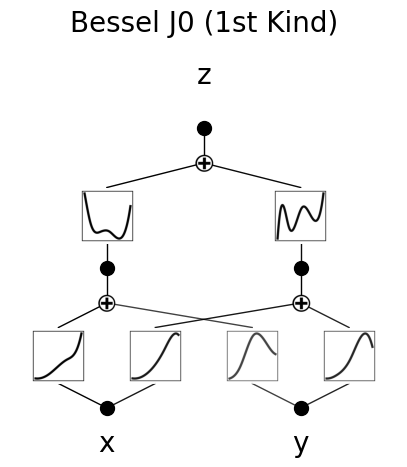

In [60]:
bessel_KAN.plot(in_vars=['x', 'y'], out_vars=['z'], title="Bessel J0 (1st Kind)")